In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import List, Tuple

# **Load Data**

In [2]:
file_path = "../data/names.txt"

with open(file_path, "r") as f:
    data = f.read()

print(data[:100])

emma
olivia
ava
isabella
sophia
charlotte
mia
amelia
harper
evelyn
abigail
emily
elizabeth
mila
ella


In [3]:
names = data.split('\n')
print("Number of names:", len(names))
names[:15]

Number of names: 32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella']

In [4]:
# Vocab
vocab = set("".join(names))
vocab.add('.')
vocab = sorted(list(vocab))

# LookUp Table
stoi={}
for i, c in enumerate(vocab):
    stoi[c]=i
itos={}
for i, c in enumerate(vocab):
    itos[i]=c

# **Create dataset for MLP training**

In [5]:
# def generate_ngrams_v2(inp_s:str, ngram_cnt:int)->List:
#     s = ['.'] + list(inp_s) + ['.']
#     shifts = []
#     for i in range(ngram_cnt):
#         shifts.append(s[i:])
    
#     return list(zip(*shifts))

# generate_ngrams_v2('under', 2)

In [6]:
def create_io_pairs(lst_s:List, context_length:int)->Tuple[torch.Tensor, torch.Tensor]:

    xs, ys = [], []
    for name in lst_s[:]:
        # print(name)
        context = [0]*context_length
        for char in name+'.':
            xs.append(context)
            ys.append(stoi[char])
            # print(f"Context: {''.join([itos[x] for x in context])} -> Label: {char}")
            context = context[1:] + [stoi[char]]

    X = torch.tensor(xs, dtype=torch.int32)
    Y = torch.tensor(ys, dtype=torch.int32)

    return X, Y

context_length=3
X, Y = create_io_pairs(names, context_length)

In [7]:
print("X.shape", X.shape)
print("Y.shape", Y.shape)

X.shape torch.Size([228146, 3])
Y.shape torch.Size([228146])


In [8]:
# Training Set
for i in range(20):
    print(f"{''.join([itos[idx.item()] for idx in X[i]])} --> {itos[Y[i].item()]}")

... --> e
..e --> m
.em --> m
emm --> a
mma --> .
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
... --> a
..a --> v
.av --> a
ava --> .
... --> i
..i --> s
.is --> a
isa --> b


# **MLP Definition and Training**

## **Note1: Generating Embedding Vectors**

**Setup:** `emb_dim = 2`, vocabulary size `V = 27`

An embedding maps each token to a dense vector in $\mathbb{R}^{\text{emb\_dim}}$.

---

### **Approach 1: One-Hot Encoding (OHE)**

Represent the input token as a one-hot vector and multiply by a weight matrix.

| Symbol | Meaning | Shape |
|:-------|:--------|:------|
| $X_{\text{inp}}$ | one-hot input | $(27 \times 1)$ |
| $W$ | embedding weight matrix | $(27 \times 2)$ |
| $X_{\text{emb}}$ | output embedding | $(1 \times 2)$ |

**Computation:**

$$
X_{\text{emb}} = X_{\text{inp}}^{\top} \, W
\quad \Rightarrow \quad (1 \times 27) \;(27 \times 2) \;\Rightarrow\; (1 \times 2)
$$

**Intuition:** If the $i$-th dimension of $X_{\text{inp}}$ is hot (equal to 1), then $X_{\text{inp}}^{\top} W$ selects **row $i$ of $W$**.

> OHE + matrix multiply = **row lookup** into $W$

---

### **Approach 2: Integer Lookup (`nn.Embedding`)**

Each vocabulary token has an integer ID. Embedding is a direct table lookup.

| Symbol | Meaning | Shape |
|:-------|:--------|:------|
| $X_{\text{inp}}$ | token index (scalar) | `()` |
| $E$ | embedding table | $(27 \times 2)$ |
| $X_{\text{emb}}$ | output embedding | $(1 \times 2)$ |

**Computation:**

$$
X_{\text{emb}} = E[X_{\text{inp}}]
\quad \Rightarrow \quad (1 \times 2)
$$

**Intuition:** If $X_{\text{inp}} = i$, then $E[i]$ returns **row $i$ of $E$**.

> Integer index + lookup = **row lookup** into $E$

---

### **Key Insight: $W$ and $E$ Are the Same Matrix**

| | OHE approach | Lookup approach |
|:--|:-------------|:----------------|
| **Matrix** | $W \in \mathbb{R}^{27 \times 2}$ | $E \in \mathbb{R}^{27 \times 2}$ |
| **Operation** | $X_{\text{inp}}^{\top} W$ | $E[X_{\text{inp}}]$ |
| **What happens** | picks row $i$ when token $i$ is hot | picks row $i$ when index is $i$ |
| **Result** | same embedding vector | same embedding vector |

Both methods store one $2$-dimensional vector per vocabulary token in a $(27 \times 2)$ table.

- **$W$** (OHE) and **$E$** (lookup) are **the same embedding matrix** — just accessed differently.
- `nn.Embedding(27, 2)` stores $E$ and does indexed lookup instead of a full one-hot multiply.
- Lookup is **faster and more memory-efficient** because we skip building a sparse $(27 \times 1)$ one-hot vector.

**PyTorch equivalents:**

```python
# Approach 1: OHE + linear (no bias)
X_emb = X_inp.T @ W          # (1, 2)

# Approach 2: embedding lookup
X_emb = E[X_inp]             # (1, 2)  — same rows as W

## **Note2: Tensor Indexing: From Submatrices to Batched Lookups**

This section explains how PyTorch's **advanced indexing** powers embedding layers—one of the most fundamental operations in deep learning.

---

### **Setup**

Consider tensor `A` with shape $(8, 8)$. We'll build intuition through increasingly complex indexing patterns.

---

### **Single Row Lookup (0D Index Tensor/Scalar)**

**Syntax:**
$$A[i] \rightarrow \text{(8,)}$$

Selecting a single row by integer index removes one dimension.

---

### **Multiple Rows LookUp (1D Index Tensor)**

**Syntax:**
$$A[\text{[0, 2, 3]}] \rightarrow \text{(3, 8)}$$

When indices are a 1D list, PyTorch returns all selected rows stacked together.

**Rule:** Index shape becomes a new leading dimension.

---

### **Batched Row Lookup (2D Index Tensor)**

**Syntax:**
$$A\begin{bmatrix} [0,2,3] \\ [2,5,7] \end{bmatrix} \rightarrow \text{(2, 3, 8)}$$

When indices form a 2D tensor of shape $(2, 3)$:
- **Batch 0:** rows $[0, 2, 3]$ → shape $(3, 8)$
- **Batch 1:** rows $[2, 5, 7]$ → shape $(3, 8)$
- **Stack:** $(2, 3, 8)$

---

### **The Golden Rule**

$$\boxed{\text{Output Shape} = \text{Index Shape} + \text{Remaining Tensor Dimensions}}$$

| Index Shape | Tensor Shape | Output Shape |
|:------------|:-------------|:-------------|
| $(2, 3)$ | $(8, 8)$ | $(2, 3, 8)$ |
| $(4,)$ | $(100, 768)$ | $(4, 768)$ |
| $(2, 3, 5)$ | $(50000, 768)$ | $(2, 3, 5, 768)$ |

---

### **Embedding Layer Connection**

An embedding matrix $E$ has shape $(V, D)$ where $V$ = vocabulary size, $D$ = embedding dimension.

Token batch of shape $(B, T)$ where $B$ = batch size, $T$ = sequence length:

$$E[\text{tokens}] \rightarrow (B, T, D)$$

**Example:**
$$E\begin{bmatrix} [12, 53, 91] \\ [44, 18, 72] \end{bmatrix} \rightarrow (2, 3, 768) \text{ if } E \text{ has shape } (50000, 768)$$

---

### **Cheat Sheet: Indexing Patterns**

| Expression | Meaning | Output Shape |
|:-----------|:--------|:-------------|
| `A[3]` | One row | `(8,)` |
| `A[[1, 3]]` | Multiple rows | `(2, 8)` |
| `A[[[1,3], [0,5]]]` | Batch of rows | `(2, 2, 8)` |
| `A[[1, 3], [0, 2]]` | Pairwise coords (zip) | `(2,)` ⚠️ |
| `A[1:4]` | Slice | `(3, 8)` |

---

### **Memory Rules**

✅ **Integer index** → removes one dimension  
✅ **Slice `:`** → preserves dimension  
✅ **List / Tensor of indices** → creates new dimension with index shape  
✅ **Index shapes broadcast into output** → exactly like embedding lookup

## **Note3: Flattening**

**Different methods of flattening**
- torch.cat()
- torch.cat() using torch.unbind()
- torch.tensor().reshape() or torch.tensor().view()
    - Memory efficient method, keeps original tensor memory preserved
    - In PyTorch, tensor elements are always stored as a 1d tensor (torch.tensor().storage())
    - Calling .view() changes only some tensor attributes that dictate how this 1D tensor is viewed as n-dimensional tensor
    - Reference Blog: https://blog.ezyang.com/2019/05/pytorch-internals/

In [9]:
g=torch.Generator().manual_seed(2147483647)
flat = torch.rand(4, 3, 2, generator=g)
print('Sample 3D tensor:')
print(flat)
print('-'*50)

# 1: torch.cat()
print('Pluck out 2D tensor from a 3D tensor')
print("i=0")
print(flat[:, 0, :])
print('-'*50)
print("i=1")
print(flat[:, 1, :])
print('-'*50)
print("Using torch.cat() to flatten the 3D tensor into a 2D tensor")
flat_v1 = torch.cat([flat[:, 0, :], flat[:, 1, :], flat[:, 2, :]], dim=1)
print(flat_v1)
print('-'*50)

# 2: torch.unbind(): Suppose we want (4, 30, 2) -> (4, 60): Not possible to use torch.cat() manually over 30 indeflates
print('Using torch.unbind() to return a list of 2D tensors from a 3D tensor')
flat_unbound = torch.unbind(flat, dim=1)
print(flat_unbound)
print("Using torch.unbind()+torch.cat() to flatten the 3D tensor into a 2D tensor")
flat_v2 = torch.cat(flat_unbound, dim=1)
print(flat_v2)
print('-'*50)

# 3: torch.reshape()/torch.view()
print('Using torch.reshape()/torch.view() to flatten the 3D tensor into a 2D tensor')
flat_v3 = flat.view(flat.shape[0], -1)
print(flat_v3)

Sample 3D tensor:
tensor([[[0.7081, 0.3542],
         [0.1054, 0.5996],
         [0.0904, 0.0899]],

        [[0.8822, 0.9887],
         [0.0080, 0.2908],
         [0.7408, 0.4012]],

        [[0.8640, 0.7391],
         [0.3845, 0.2176],
         [0.7054, 0.9882]],

        [[0.9600, 0.4388],
         [0.7074, 0.0554],
         [0.8117, 0.3059]]])
--------------------------------------------------
Pluck out 2D tensor from a 3D tensor
i=0
tensor([[0.7081, 0.3542],
        [0.8822, 0.9887],
        [0.8640, 0.7391],
        [0.9600, 0.4388]])
--------------------------------------------------
i=1
tensor([[0.1054, 0.5996],
        [0.0080, 0.2908],
        [0.3845, 0.2176],
        [0.7074, 0.0554]])
--------------------------------------------------
Using torch.cat() to flatten the 3D tensor into a 2D tensor
tensor([[0.7081, 0.3542, 0.1054, 0.5996, 0.0904, 0.0899],
        [0.8822, 0.9887, 0.0080, 0.2908, 0.7408, 0.4012],
        [0.8640, 0.7391, 0.3845, 0.2176, 0.7054, 0.9882],
        

## **Note4: Using troch.nn.functional.cross_entropy()**

**NLL Loss using by-hand notation**
- counts = logits.exp()
- probs = counts/counts.sum(dim=-1, keepdim=True)
- loss = -1 * (probs[torch.arange(B), labels].log().mean())

**CCE Loss using PyTorch built-in function**
- loss = F.cross_entropy(logits, label)
- Much more efficient and intermediate tensors are not created, PyTorch has a fused kernel implementation for this
- Mathematically NLL and CCE loss is the same thing
- Internally does safe softmax to handle overflow
    - Note that when logit values are negative, we are OK
    - When logit values are mildly positive, because od exp() function, we often run in overflow error
    - This is handled by safe softmax


In [10]:
class MLP:
    
    def __init__(self, ctx_len:int, vocab:List)->None:
        g = torch.Generator().manual_seed(42)
        self.emb_dim = 2
        self.C = torch.randn((len(vocab), self.emb_dim), generator=g)
        self.W1 = torch.randn((self.emb_dim*ctx_len, 64), generator=g)
        self.b1 = torch.randn((64,), generator=g)
        self.W2 = torch.randn((64, len(vocab)), generator=g)
        self.b2 = torch.randn((len(vocab),), generator=g)
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2]

    def forward(self, x_inp:torch.Tensor, label:torch.Tensor, is_test:bool=False)->torch.Tensor:

        # Extract embeddings
        x_emb = self.C[x_inp, :]
        B = x_emb.shape[0]
        # Flatten embeddings across context length
        x_emb_flatened = x_emb.view(B, -1)
        # Layer1
        h1 = x_emb_flatened @ self.W1 + self.b1
        # Activation
        a1 = torch.tanh(h1)
        # Layer 2
        h2 = a1 @ self.W2 + self.b2
        if is_test:
            # Softmax
            cnts = h2.exp()
            probs = cnts/cnts.sum(dim=-1, keepdim=True)
            # For each row in batch, we have a prob vector of size:vocab_len-> pluck out prob of corresponding label
            nll_loss_byhand = -1 * (probs[torch.arange(B), label].log().mean().item())
            # using torch.nn.functional.cross_entropy() to compute the loss
            nll_loss = F.cross_entropy(h2, label)
        
        
        if is_test:
            print("x_inp:", x_inp.shape)
            print("x_emb:", x_emb.shape)
            print("x_emb_flatened:", x_emb_flatened.shape)
            print("h1:", h1.shape)
            print("h2:", h2.shape)
            print("probs:", probs.shape)
            print("nll_loss_byhand:", nll_loss_byhand)
            print("nll_loss:", nll_loss)

        return h2



context_length=3
model = MLP(context_length, vocab)

sample_inp_idxs = [3, 4, 8, 9, 101]
sample_inp = X[sample_inp_idxs]
sample_labels = Y[sample_inp_idxs]
_ = model.forward(sample_inp, sample_labels.long(), is_test=True)

x_inp: torch.Size([5, 3])
x_emb: torch.Size([5, 3, 2])
x_emb_flatened: torch.Size([5, 6])
h1: torch.Size([5, 64])
h2: torch.Size([5, 27])
probs: torch.Size([5, 27])
nll_loss_byhand: 11.568570137023926
nll_loss: tensor(11.5686)


In [11]:
# Instantiate model
context_length=3
model = MLP(context_length, vocab)
print("Total Model Params:", sum(p.nelement() for p in model.parameters))
for p in model.parameters:
    p.requires_grad = True

# Train Loop: Implement Batch Grad Descent (BGD)
total_samples=X.shape[0]
num_epochs = 50
lst_lr=[0.1, 1, 3]
loss_register_bgd = {}

for lr in lst_lr:
    print(f"Training with learning rate: {lr}")
    print('-'*50)
    loss_register_bgd[lr]=[]
    for epoch in range(num_epochs):

        # Forward pass
        logits = model.forward(X, Y.long())
        nll_loss = F.cross_entropy(logits, Y.long())

        # Backward pass
        for p in model.parameters:
            p.grad = None
        nll_loss.backward()

        # Update parameters
        for p in model.parameters:
            p.data += -lr * p.grad

        loss_register_bgd[lr].append(nll_loss.item())
        print(f"Epoch: {epoch+1}/{num_epochs}, Loss: {loss_register_bgd[lr][-1]:.4f}")

    print('-'*100)
    print(f"Final loss after {num_epochs} epochs: {loss_register_bgd[lr][-1]:4f}")
    print('-'*100)
    

Total Model Params: 2257
Training with learning rate: 0.1
--------------------------------------------------
Epoch: 1/50, Loss: 14.9639
Epoch: 2/50, Loss: 14.2774
Epoch: 3/50, Loss: 13.6402
Epoch: 4/50, Loss: 13.0509
Epoch: 5/50, Loss: 12.5126
Epoch: 6/50, Loss: 12.0257
Epoch: 7/50, Loss: 11.5761
Epoch: 8/50, Loss: 11.1629
Epoch: 9/50, Loss: 10.7907
Epoch: 10/50, Loss: 10.4429
Epoch: 11/50, Loss: 10.1121
Epoch: 12/50, Loss: 9.7970
Epoch: 13/50, Loss: 9.5000
Epoch: 14/50, Loss: 9.2273
Epoch: 15/50, Loss: 8.9806
Epoch: 16/50, Loss: 8.7525
Epoch: 17/50, Loss: 8.5356
Epoch: 18/50, Loss: 8.3264
Epoch: 19/50, Loss: 8.1239
Epoch: 20/50, Loss: 7.9276
Epoch: 21/50, Loss: 7.7374
Epoch: 22/50, Loss: 7.5534
Epoch: 23/50, Loss: 7.3758
Epoch: 24/50, Loss: 7.2053
Epoch: 25/50, Loss: 7.0421
Epoch: 26/50, Loss: 6.8867
Epoch: 27/50, Loss: 6.7393
Epoch: 28/50, Loss: 6.5995
Epoch: 29/50, Loss: 6.4669
Epoch: 30/50, Loss: 6.3410
Epoch: 31/50, Loss: 6.2212
Epoch: 32/50, Loss: 6.1070
Epoch: 33/50, Loss: 5.998

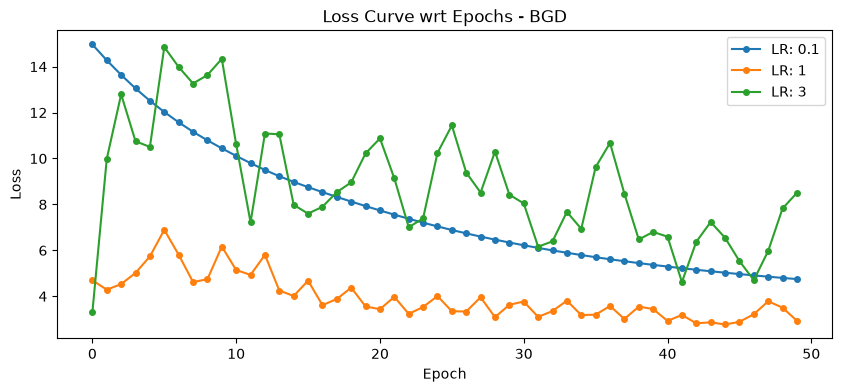

In [12]:
# Plot Loss
plt.figure(figsize=(10, 4))
for lr in lst_lr:
    plt.plot(loss_register_bgd[lr], marker='o', markersize=4, label=f'LR: {lr}')
plt.title("Loss Curve wrt Epochs - BGD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
# Instantiate model
context_length=3
model = MLP(context_length, vocab)
print("Total Model Params:", sum(p.nelement() for p in model.parameters))
for p in model.parameters:
    p.requires_grad = True

# Train Loop: Implement MiniBatch Grad Descent (BGD)
total_samples=X.shape[0]
batch_size=int(228146/32)
num_epochs = 50
lst_lr=[0.1, 1]
loss_register_mbgd = {}

for lr in lst_lr:
    print(f"Training with learning rate: {lr}")
    print('-'*50)
    loss_register_mbgd[lr]=[]
    for epoch in range(num_epochs):

        loss_epoch = 0.0
        cnt_samples = 0
        
        # Construct mini-batch
        ix = torch.randint(0, total_samples, (total_samples,))

        for i in range(0, total_samples, batch_size):
            
            # Create X_minibatch and Y_minibatch
            minibatch_idxs = ix[i:i+batch_size]
            X_minibatch = X[minibatch_idxs]
            Y_minibatch = Y[minibatch_idxs]

            # Forward pass
            logits = model.forward(X_minibatch, Y_minibatch.long())
            nll_loss = F.cross_entropy(logits, Y_minibatch.long())

            # Backward pass
            for p in model.parameters:
                p.grad = None
            nll_loss.backward()

            # Update parameters
            for p in model.parameters:
                p.data += -lr * p.grad

            loss_epoch += nll_loss.item() * X_minibatch.shape[0]
            cnt_samples += X_minibatch.shape[0]

        norm_loss_epoch = loss_epoch / cnt_samples

        loss_register_mbgd[lr].append(norm_loss_epoch)
        print(f"Epoch: {epoch+1}/{num_epochs}, Loss: {loss_register_mbgd[lr][-1]}")

    print('-'*100)
    print(f"Final loss after {num_epochs} epochs: {loss_register_mbgd[lr][-1]:4f}")
    print('-'*100)
    

Total Model Params: 2257
Training with learning rate: 0.1
--------------------------------------------------
Epoch: 1/50, Loss: 9.259785443496055
Epoch: 2/50, Loss: 4.909169405448231
Epoch: 3/50, Loss: 3.8877232450832078
Epoch: 4/50, Loss: 3.466973386792508
Epoch: 5/50, Loss: 3.2587822955834715
Epoch: 6/50, Loss: 3.094034785524114
Epoch: 7/50, Loss: 2.999864154528601
Epoch: 8/50, Loss: 2.912785561317809
Epoch: 9/50, Loss: 2.85323497409856
Epoch: 10/50, Loss: 2.788023476734494
Epoch: 11/50, Loss: 2.74362254053725
Epoch: 12/50, Loss: 2.7146925987248482
Epoch: 13/50, Loss: 2.6873191277170054
Epoch: 14/50, Loss: 2.662953435962401
Epoch: 15/50, Loss: 2.6411781198423117
Epoch: 16/50, Loss: 2.618842241879502
Epoch: 17/50, Loss: 2.6047864538761343
Epoch: 18/50, Loss: 2.6020051219309877
Epoch: 19/50, Loss: 2.583068684659312
Epoch: 20/50, Loss: 2.5751871099701784
Epoch: 21/50, Loss: 2.5660923983902295
Epoch: 22/50, Loss: 2.5588823774683513
Epoch: 23/50, Loss: 2.5455660328855396
Epoch: 24/50, Los

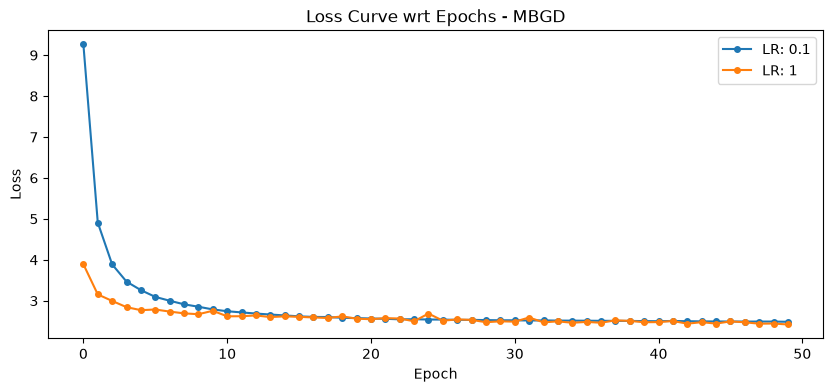

In [14]:
# Plot Loss
plt.figure(figsize=(10, 4))
for lr in lst_lr:
    plt.plot(loss_register_mbgd[lr], marker='o', markersize=4, label=f'LR: {lr}')
plt.title("Loss Curve wrt Epochs - MBGD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **How to find good initial learning rates empirically?**

Steps:
- Choose a upper and lower bounds for learning rates we want to try
- Create lre and lrs
    - lre: is a list linearly seperated values
    - lrs: is a list of learning rates, we exponentiate the lre values to obtain learning rates
        - For example: if we want to try leaning rates of 10e-2 to 10e1, then choose
        - lre: [-2 to +1, linearly seperated by say x points], let us say x=1000
        - lrs: torch.exp(lre)
- Now run training loop over a minibatch of sufficient size
- How many times do we run the training loop?
    - Same as the total distinct lrs we have
    - Idea is for every minibatch update, we use a unique lr from our list of lrs and note down the loss and corresponding lr
    - Then we can visually inspect into a good learning value

In [15]:
lre = torch.linspace(-3, 0.5, 1000)
lrs = 10**lre


# Instantiate model
context_length=3
model = MLP(context_length, vocab)
print("Total Model Params:", sum(p.nelement() for p in model.parameters))
for p in model.parameters:
    p.requires_grad = True

lri = []
lossi = []
for i in range(lrs.shape[0]):

    # Create minibatch idxs: Batch size = 32, total_samples = 228146
    ix = torch.randint(0, total_samples, (32,))

    X_minibatch = X[ix]
    Y_minibatch = Y[ix]

    # Forward pass
    logits = model.forward(X_minibatch, Y_minibatch.long())
    # Compute loss
    nll_loss = F.cross_entropy(logits, Y_minibatch.long())
    print(f"Loss: {nll_loss.item():.4f}")

    # Backward pass
    for p in model.parameters:
        p.grad = None
    nll_loss.backward()

    # Update parameters
    for p in model.parameters:
        p.data += -lrs[i] * p.grad

    # LR Stats
    lri.append(lre[i])
    lossi.append(nll_loss.item())   



Total Model Params: 2257
Loss: 13.8568
Loss: 15.6533
Loss: 12.9900
Loss: 13.6666
Loss: 14.3152
Loss: 16.2557
Loss: 18.2387
Loss: 14.1662
Loss: 13.7723
Loss: 13.8679
Loss: 13.7535
Loss: 16.2918
Loss: 14.2435
Loss: 14.3392
Loss: 17.0135
Loss: 14.3668
Loss: 15.5433
Loss: 13.2776
Loss: 12.6947
Loss: 13.8794
Loss: 14.6738
Loss: 13.5325
Loss: 17.7794
Loss: 13.3006
Loss: 14.6565
Loss: 14.2993
Loss: 14.8956
Loss: 15.3119
Loss: 13.8617
Loss: 12.4397
Loss: 13.5776
Loss: 13.1887
Loss: 14.9876
Loss: 14.8712
Loss: 15.3287
Loss: 14.4420
Loss: 17.0985
Loss: 16.3590
Loss: 15.8006
Loss: 14.4215
Loss: 14.4260
Loss: 13.7172
Loss: 13.2596
Loss: 14.3118
Loss: 12.6917
Loss: 13.6142
Loss: 14.4507
Loss: 14.3234
Loss: 13.8386
Loss: 13.3764
Loss: 14.0872
Loss: 16.0861
Loss: 14.0148
Loss: 14.2904
Loss: 14.7712
Loss: 16.4356
Loss: 14.5578
Loss: 12.4838
Loss: 15.4988
Loss: 14.9650
Loss: 15.6272
Loss: 13.7667
Loss: 15.0429
Loss: 14.0731
Loss: 15.2585
Loss: 15.5387
Loss: 13.9611
Loss: 14.4406
Loss: 15.7867
Loss: 13.

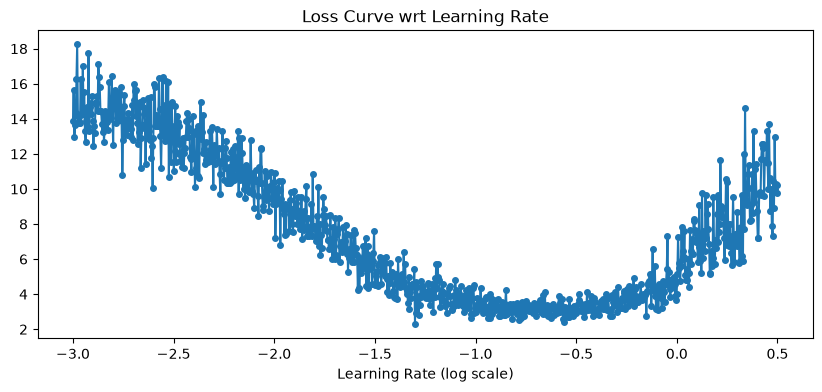

In [16]:
# Inspect optimal learning rate
plt.figure(figsize=(10, 4))
plt.plot(lri, lossi, marker='o', markersize=4)
plt.title("Loss Curve wrt Learning Rate")
plt.xlabel("Learning Rate (log scale)")
plt.show()

In [17]:
print(f"Good LRs - Lower bound: {10**-1:.4f}")
print(f"Good LRs - Lower bound: {10**-0.51:.4f}")

Good LRs - Lower bound: 0.1000
Good LRs - Lower bound: 0.3090
